# Pythagorean Theorem — A Visual Proof

We prove that for any right triangle with legs $a$, $b$ and hypotenuse $c$:

$$a^2 + b^2 = c^2$$

using a beautiful geometric argument that requires nothing more than computing areas two different ways.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.patches import FancyArrowPatch

## Step 1 — The Setup

Start with a right triangle whose legs have lengths $a$ and $b$, and whose hypotenuse has length $c$.

Now draw a **big square** with side length $(a + b)$. Place **four copies** of the right triangle inside, arranged so that their hypotenuses form a **tilted inner square** of side length $c$.

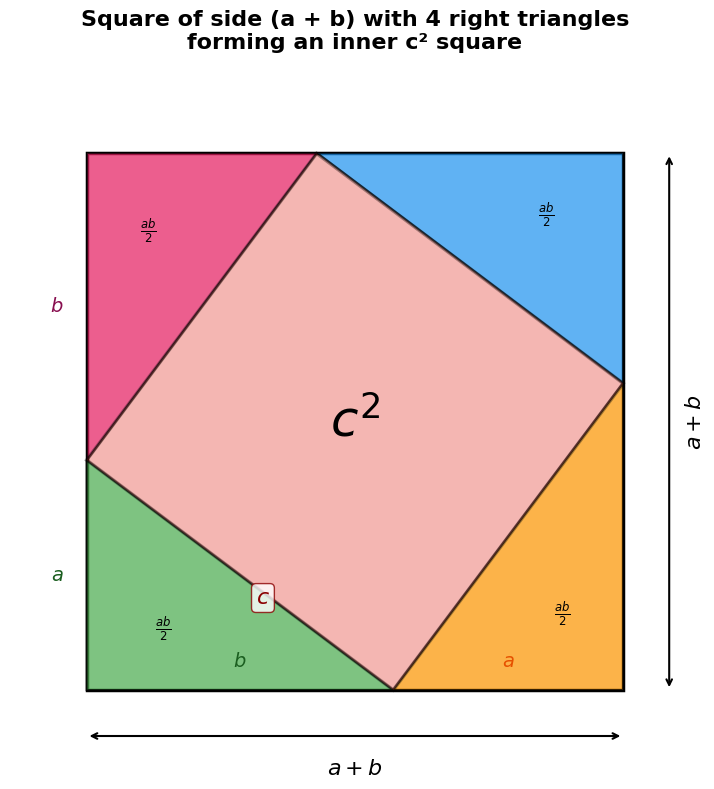

In [2]:
# === DIAGRAM 1: Square of side (a+b) with tilted inner c² square ===

a, b = 3, 4
s = a + b  # side of outer square

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_xlim(-1, s + 1)
ax.set_ylim(-1, s + 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Square of side (a + b) with 4 right triangles\nforming an inner c² square',
             fontsize=16, fontweight='bold', pad=20)

# Outer square
outer = patches.Rectangle((0, 0), s, s, linewidth=2.5,
                           edgecolor='black', facecolor='#f5f5f5')
ax.add_patch(outer)

# Four right-triangle vertices (counter-clockwise from bottom-left)
# Triangle 1: bottom-left corner
tri1 = plt.Polygon([(0, 0), (b, 0), (0, a)], closed=True,
                    facecolor='#4CAF50', edgecolor='black', linewidth=1.5, alpha=0.7)
# Triangle 2: bottom-right corner
tri2 = plt.Polygon([(b, 0), (s, 0), (s, b)], closed=True,
                    facecolor='#FF9800', edgecolor='black', linewidth=1.5, alpha=0.7)
# Triangle 3: top-right corner
tri3 = plt.Polygon([(s, b), (s, s), (a, s)], closed=True,
                    facecolor='#2196F3', edgecolor='black', linewidth=1.5, alpha=0.7)
# Triangle 4: top-left corner
tri4 = plt.Polygon([(a, s), (0, s), (0, a)], closed=True,
                    facecolor='#E91E63', edgecolor='black', linewidth=1.5, alpha=0.7)

for tri in [tri1, tri2, tri3, tri4]:
    ax.add_patch(tri)

# Inner c² square (the tilted square)
inner = plt.Polygon([(0, a), (b, 0), (s, b), (a, s)], closed=True,
                     facecolor='#F44336', edgecolor='black', linewidth=2.5, alpha=0.35)
ax.add_patch(inner)
ax.text(s/2, s/2, '$c^2$', fontsize=36, ha='center', va='center', fontweight='bold')

# Label the outer sides
ax.annotate('', xy=(s, -0.6), xytext=(0, -0.6),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(s/2, -0.9, '$a + b$', fontsize=16, ha='center', va='top')

ax.annotate('', xy=(s + 0.6, s), xytext=(s + 0.6, 0),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(s + 0.8, s/2, '$a + b$', fontsize=16, ha='left', va='center', rotation=90)

# Label triangle legs on bottom edge
ax.text(b/2, 0.25, '$b$', fontsize=14, ha='center', va='bottom', color='#1B5E20', fontweight='bold')
ax.text((b + s)/2, 0.25, '$a$', fontsize=14, ha='center', va='bottom', color='#E65100', fontweight='bold')

# Label triangle legs on left edge
ax.text(-0.3, a/2, '$a$', fontsize=14, ha='right', va='center', color='#1B5E20', fontweight='bold')
ax.text(-0.3, (a + s)/2, '$b$', fontsize=14, ha='right', va='center', color='#880E4F', fontweight='bold')

# Label a hypotenuse
ax.text(b/2 + 0.3, a/2 - 0.3, '$c$', fontsize=16, ha='center', va='center',
        fontweight='bold', color='darkred',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='darkred', alpha=0.8))

# Label each triangle
ax.text(1.0, 0.8, '$\\frac{ab}{2}$', fontsize=12, ha='center', va='center')
ax.text(s - 0.8, 1.0, '$\\frac{ab}{2}$', fontsize=12, ha='center', va='center')
ax.text(s - 1.0, s - 0.8, '$\\frac{ab}{2}$', fontsize=12, ha='center', va='center')
ax.text(0.8, s - 1.0, '$\\frac{ab}{2}$', fontsize=12, ha='center', va='center')

plt.tight_layout()
plt.show()

## Step 2 — Two Ways to Compute the Area

The area of the **outer square** is:

$$(a + b)^2$$

But we can also compute it as the **inner square** plus the **four triangles**:

$$c^2 + 4 \cdot \frac{ab}{2} = c^2 + 2ab$$

Setting them equal:

$$(a + b)^2 = c^2 + 2ab$$

Expanding the left side:

$$a^2 + 2ab + b^2 = c^2 + 2ab$$

**Cancel** $2ab$ from both sides:

$$a^2 + \cancel{2ab} + b^2 = c^2 + \cancel{2ab}$$

$$\boxed{a^2 + b^2 = c^2}$$

That's it! ✅

## Step 3 — The Rearrangement

To really see *why* $2ab$ cancels, let's rearrange the same $(a+b)$ square in two different ways:

- **Left**: the 4 triangles leave a tilted $c^2$ hole → area = $c^2 + 2ab$
- **Right**: push the triangles into the corners to form two $a \times b$ rectangles, leaving an $a^2$ square and a $b^2$ square → area = $a^2 + b^2 + 2ab$

Since both arrangements fill the **same** outer square, the non-triangle areas must be equal: $c^2 = a^2 + b^2$.

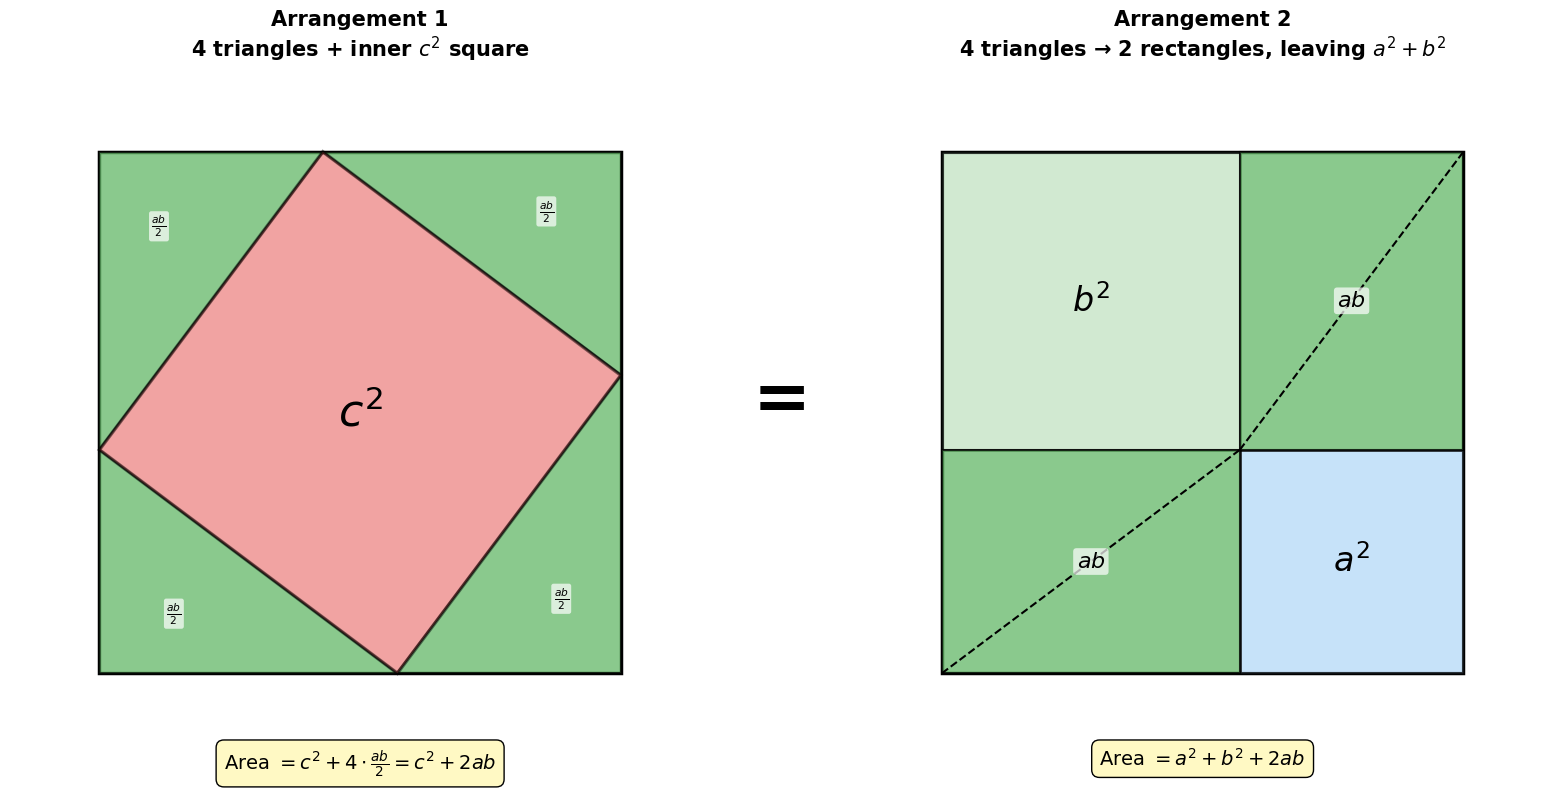

In [3]:
# === DIAGRAM 2: Side-by-side rearrangement ===

a, b = 3, 4
s = a + b

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8))

# ──────────── LEFT: Tilted c² square arrangement ────────────
ax1.set_xlim(-1.2, s + 1.2)
ax1.set_ylim(-1.5, s + 1)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Arrangement 1\n4 triangles + inner $c^2$ square',
              fontsize=15, fontweight='bold', pad=15)

# Outer square
ax1.add_patch(patches.Rectangle((0, 0), s, s, lw=2.5, ec='black', fc='#f5f5f5'))

# Four triangles
tri_color = '#66BB6A'
tris1 = [
    [(0, 0), (b, 0), (0, a)],
    [(b, 0), (s, 0), (s, b)],
    [(s, b), (s, s), (a, s)],
    [(a, s), (0, s), (0, a)],
]
for t in tris1:
    ax1.add_patch(plt.Polygon(t, fc=tri_color, ec='black', lw=1.5, alpha=0.75))

# Inner tilted square
ax1.add_patch(plt.Polygon([(0, a), (b, 0), (s, b), (a, s)],
                          fc='#EF5350', ec='black', lw=2.5, alpha=0.5))
ax1.text(s/2, s/2, '$c^2$', fontsize=32, ha='center', va='center', fontweight='bold')

# Label triangles
for (cx, cy) in [(1.0, 0.8), (s-0.8, 1.0), (s-1.0, s-0.8), (0.8, s-1.0)]:
    ax1.text(cx, cy, '$\\frac{ab}{2}$', fontsize=11, ha='center', va='center',
             bbox=dict(fc='white', ec='none', alpha=0.7, boxstyle='round,pad=0.15'))

# Area equation below
ax1.text(s/2, -1.0, 'Area $= c^2 + 4 \\cdot \\frac{ab}{2} = c^2 + 2ab$',
         fontsize=14, ha='center', va='top',
         bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

# ──────────── RIGHT: a² + b² + 2ab arrangement ────────────
ax2.set_xlim(-1.2, s + 1.2)
ax2.set_ylim(-1.5, s + 1)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Arrangement 2\n4 triangles → 2 rectangles, leaving $a^2 + b^2$',
              fontsize=15, fontweight='bold', pad=15)

# Outer square
ax2.add_patch(patches.Rectangle((0, 0), s, s, lw=2.5, ec='black', fc='#f5f5f5'))

# a² square (bottom-right)
ax2.add_patch(patches.Rectangle((b, 0), a, a, lw=2, ec='black', fc='#BBDEFB', alpha=0.8))
ax2.text(b + a/2, a/2, '$a^2$', fontsize=24, ha='center', va='center', fontweight='bold')

# b² square (top-left)
ax2.add_patch(patches.Rectangle((0, a), b, b, lw=2, ec='black', fc='#C8E6C9', alpha=0.8))
ax2.text(b/2, a + b/2, '$b^2$', fontsize=24, ha='center', va='center', fontweight='bold')

# Rectangle ab (bottom-left) — made of 2 triangles
ax2.add_patch(patches.Rectangle((0, 0), b, a, lw=1.5, ec='black', fc=tri_color, alpha=0.75))
# Show diagonal to indicate 2 triangles
ax2.plot([0, b], [0, a], 'k--', lw=1.5)
ax2.text(b/2, a/2, '$ab$', fontsize=16, ha='center', va='center', fontweight='bold',
         bbox=dict(fc='white', ec='none', alpha=0.7, boxstyle='round,pad=0.15'))

# Rectangle ab (top-right) — made of 2 triangles
ax2.add_patch(patches.Rectangle((b, a), a, b, lw=1.5, ec='black', fc=tri_color, alpha=0.75))
# Show diagonal to indicate 2 triangles
ax2.plot([b, s], [a, s], 'k--', lw=1.5)
ax2.text(b + a/2, a + b/2, '$ab$', fontsize=16, ha='center', va='center', fontweight='bold',
         bbox=dict(fc='white', ec='none', alpha=0.7, boxstyle='round,pad=0.15'))

# Area equation below
ax2.text(s/2, -1.0, 'Area $= a^2 + b^2 + 2ab$',
         fontsize=14, ha='center', va='top',
         bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

# Big equals sign between the two
fig.text(0.5, 0.5, '=', fontsize=50, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 4 — The Cancellation

Both arrangements fill the **exact same** $(a+b)$ square, so they have the **same total area**.

In both, the **4 triangles** occupy a combined area of $2ab$.

So the **remaining** (non-triangle) area must also be equal:

| Arrangement 1 | Arrangement 2 |
|:-:|:-:|
| $c^2 + 2ab$ | $a^2 + b^2 + 2ab$ |

Subtract the $2ab$ (the 4 triangles) from both:

$$c^2 = a^2 + b^2 \quad \checkmark$$

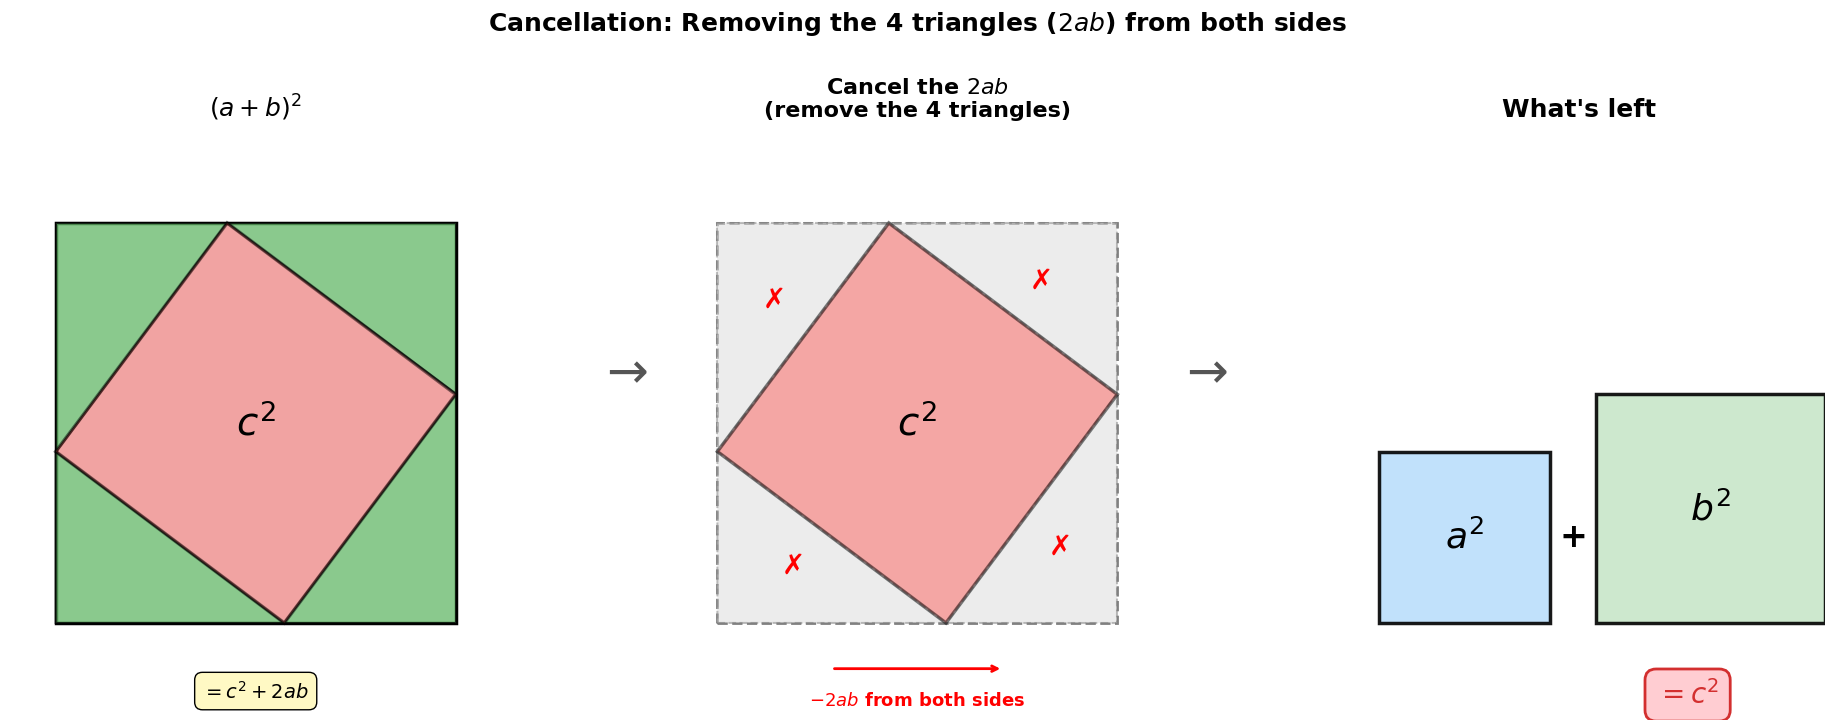

In [4]:
# === DIAGRAM 3: Cancellation visualized — subtract 2ab from both sides ===

a, b = 3, 4
s = a + b

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

tri_color = '#66BB6A'
cancel_color = '#E0E0E0'

# ───── Panel 1: (a+b)² = c² + 2ab ─────
ax = axes[0]
ax.set_xlim(-0.8, s + 0.8)
ax.set_ylim(-1.5, s + 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('$(a+b)^2$', fontsize=18, fontweight='bold', pad=15)

ax.add_patch(patches.Rectangle((0, 0), s, s, lw=2.5, ec='black', fc='#f5f5f5'))
for t in [[(0,0),(b,0),(0,a)], [(b,0),(s,0),(s,b)],
          [(s,b),(s,s),(a,s)], [(a,s),(0,s),(0,a)]]:
    ax.add_patch(plt.Polygon(t, fc=tri_color, ec='black', lw=1.5, alpha=0.75))
ax.add_patch(plt.Polygon([(0,a),(b,0),(s,b),(a,s)],
                         fc='#EF5350', ec='black', lw=2.5, alpha=0.5))
ax.text(s/2, s/2, '$c^2$', fontsize=28, ha='center', va='center', fontweight='bold')
ax.text(s/2, -1.0, '$= c^2 + 2ab$', fontsize=14, ha='center', va='top',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

# ───── Panel 2: Subtract the 2ab (greyed out triangles) ─────
ax = axes[1]
ax.set_xlim(-0.8, s + 0.8)
ax.set_ylim(-1.5, s + 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Cancel the $2ab$\n(remove the 4 triangles)', fontsize=16, fontweight='bold', pad=15)

# Show outer square faded
ax.add_patch(patches.Rectangle((0, 0), s, s, lw=2, ec='grey', fc='#fafafa', ls='--'))

# Greyed out / crossed-out triangles
for t in [[(0,0),(b,0),(0,a)], [(b,0),(s,0),(s,b)],
          [(s,b),(s,s),(a,s)], [(a,s),(0,s),(0,a)]]:
    ax.add_patch(plt.Polygon(t, fc=cancel_color, ec='grey', lw=1.5, alpha=0.5, ls='--'))
    # Draw X through each triangle
    cx = np.mean([p[0] for p in t])
    cy = np.mean([p[1] for p in t])
    ax.text(cx, cy, '✗', fontsize=20, ha='center', va='center', color='red', fontweight='bold')

# Inner tilted square still colored
ax.add_patch(plt.Polygon([(0,a),(b,0),(s,b),(a,s)],
                         fc='#EF5350', ec='black', lw=2.5, alpha=0.5))
ax.text(s/2, s/2, '$c^2$', fontsize=28, ha='center', va='center', fontweight='bold')

# Big arrow
ax.annotate('', xy=(s/2 + 1.5, -0.8), xytext=(s/2 - 1.5, -0.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.text(s/2, -1.2, '$- 2ab$ from both sides', fontsize=13, ha='center', va='top', color='red',
        fontweight='bold')

# ───── Panel 3: What's left → a² + b² = c² ─────
ax = axes[2]
ax.set_xlim(-0.8, s + 0.8)
ax.set_ylim(-1.5, s + 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("What's left", fontsize=18, fontweight='bold', pad=15)

# Show the a² and b² squares that remain when triangles are removed
# a² square
ax.add_patch(patches.Rectangle((0, 0), a, a, lw=2.5, ec='black', fc='#BBDEFB', alpha=0.9))
ax.text(a/2, a/2, '$a^2$', fontsize=26, ha='center', va='center', fontweight='bold')

# + sign
ax.text(a + 0.4, a/2, '+', fontsize=24, ha='center', va='center', fontweight='bold')

# b² square (shifted right for visual clarity)
b_offset_x = a + 0.8
ax.add_patch(patches.Rectangle((b_offset_x, 0), b, b, lw=2.5, ec='black', fc='#C8E6C9', alpha=0.9))
ax.text(b_offset_x + b/2, b/2, '$b^2$', fontsize=26, ha='center', va='center', fontweight='bold')

# = c²
ax.text((a + b_offset_x + b) / 2, -1.0, '$= c^2$', fontsize=20, ha='center', va='top',
        fontweight='bold', color='#D32F2F',
        bbox=dict(fc='#FFCDD2', ec='#D32F2F', boxstyle='round,pad=0.4', lw=2))

# Equals between panels
fig.text(0.355, 0.5, '→', fontsize=36, ha='center', va='center', color='#555')
fig.text(0.645, 0.5, '→', fontsize=36, ha='center', va='center', color='#555')

plt.suptitle('Cancellation: Removing the 4 triangles ($2ab$) from both sides',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary

The key insight is stunningly simple:

1. **Build** a square of side $(a+b)$ — its area is $(a+b)^2$.
2. **Fill** it with 4 right triangles + a tilted $c^2$ square → area $= c^2 + 2ab$.
3. **Rearrange** the same 4 triangles to leave $a^2 + b^2$ → area $= a^2 + b^2 + 2ab$.
4. **Same** outer square, **same** 4 triangles → the leftovers must be equal:

$$c^2 = a^2 + b^2 \quad \blacksquare$$

In [5]:
# === DIAGRAM 4: Numerical verification with a = 3, b = 4, c = 5 ===

a, b = 3, 4
c = np.sqrt(a**2 + b**2)

print(f"a = {a}, b = {b}")
print(f"c = √(a² + b²) = √({a**2} + {b**2}) = √{a**2 + b**2} = {c:.0f}")
print()
print(f"(a + b)²  = {(a+b)**2}")
print(f"c² + 2ab  = {c**2:.0f} + {2*a*b} = {c**2 + 2*a*b:.0f}  ✓")
print(f"a² + b²   = {a**2} + {b**2} = {a**2 + b**2}")
print(f"c²        = {c**2:.0f}")
print()
print(f"a² + b² = c²  →  {a**2 + b**2} = {c**2:.0f}  ✓  Pythagorean Theorem confirmed!")

a = 3, b = 4
c = √(a² + b²) = √(9 + 16) = √25 = 5

(a + b)²  = 49
c² + 2ab  = 25 + 24 = 49  ✓
a² + b²   = 9 + 16 = 25
c²        = 25

a² + b² = c²  →  25 = 25  ✓  Pythagorean Theorem confirmed!
